# PROJET CAPSTONE — DÉTECTION D'ATTAQUES DE CYBERSÉCURITÉ (IDS)

**Contexte :** Une PME souhaite détecter des intrusions réseau à partir de logs systèmes.  
**Dataset :** CIC-IDS2017 (Canadian Institute for Cybersecurity)  
**Modèle :** XGBoost — classification binaire + multi-classe  

---

## Plan du projet

| Étape | Description |
|-------|-------------|
| 0 | Importation des librairies |
| 1 | Chargement et fusion des données |
| 2 | Nettoyage (doublons, NaN, infinis, mémoire) |
| 3 | Encodage des variables catégorielles |
| 4 | Construction du Pipeline sklearn (IQR + RobustScaler) |
| 5 | Split Train/Test + Application du pipeline |
| 6 | Analyse Exploratoire (EDA + boxplots avant/après) |
| 7 | Classification Binaire + Cross-validation + Threshold tuning + Courbe PR |
| 8 | Classification Multi-classe + SMOTE + Courbe PR + Analyse des erreurs |
| 9 | Bilan comparatif |
| 10 | Simulation temps réel & Sauvegarde |

---
## ÉTAPE 0 — Importation des librairies

In [33]:
# ================================================================
# ÉTAPE 0 — IMPORTATION DES LIBRAIRIES
# ================================================================

import gdown
import pandas as pd
import numpy as np
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement & Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from collections import Counter

# Modèle
from xgboost import XGBClassifier

# Évaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

# Sauvegarde
import joblib

print('Toutes les librairies importées avec succès.')

Toutes les librairies importées avec succès.


---
## ÉTAPE 1 — Chargement et fusion des données

In [34]:
# ================================================================
# ÉTAPE 1.1 — CHARGEMENT AVEC CACHE
# ================================================================

DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

file_ids = [
    '1yeaLeHPq6kiPCQeHrA0E8IXV5jKTuIur',
    '1cPQyVex5SNYi3lb4prxxeHRHjDI_2fyJ',
    '1V9jv2-7lhDQirwzzKLbPmfFk3IA8p49E',
    '1u2PoxIwP9A9vzKG-4xLIzY4RNuc70Gin',
    '1yWAzTGzhO6v5XsgGrup6ECACMsKDuoGv',
    '1cUsqRX1D_R2kdlGddNkjtA7U5DdFaW7Y',
    '1RrTLvR1rSULSyWOjSmd1IWun3bNo0UnW',
    '1g6LPnI1KSG7oc-4zmc3pBcuQcPN_AvE9',
]

file_paths = []
for file_id in file_ids:
    output_path = DATA_DIR / f'{file_id}.csv'
    if not output_path.exists():
        gdown.download(f'https://drive.google.com/uc?id={file_id}',
                       str(output_path), quiet=False)
    else:
        print(f'Cache OK : {output_path.name}')
    file_paths.append(output_path)

print(f'\n{len(file_paths)} fichiers prêts.')

Cache OK : 1yeaLeHPq6kiPCQeHrA0E8IXV5jKTuIur.csv
Cache OK : 1cPQyVex5SNYi3lb4prxxeHRHjDI_2fyJ.csv
Cache OK : 1V9jv2-7lhDQirwzzKLbPmfFk3IA8p49E.csv
Cache OK : 1u2PoxIwP9A9vzKG-4xLIzY4RNuc70Gin.csv
Cache OK : 1yWAzTGzhO6v5XsgGrup6ECACMsKDuoGv.csv
Cache OK : 1cUsqRX1D_R2kdlGddNkjtA7U5DdFaW7Y.csv
Cache OK : 1RrTLvR1rSULSyWOjSmd1IWun3bNo0UnW.csv
Cache OK : 1g6LPnI1KSG7oc-4zmc3pBcuQcPN_AvE9.csv

8 fichiers prêts.


In [35]:
# ================================================================
# ÉTAPE 1.2 — FUSION
# ================================================================

dfs = [pd.read_csv(p) for p in file_paths]
df  = pd.concat(dfs, ignore_index=True)

print(f'Dimensions brutes : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
df.head(3)

Dimensions brutes : 2,830,743 lignes x 79 colonnes


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


---
## ÉTAPE 2 — Nettoyage des données

In [36]:
# ================================================================
# ÉTAPE 2 — NETTOYAGE COMPLET
# ================================================================

# 2.1 Nettoyage des noms de colonnes
df.columns = df.columns.str.strip()

# 2.2 Suppression colonnes identifiantes (anti data leakage)
# IP, ports source, timestamps -> l'IA apprendrait des adresses machines
# spécifiques plutôt que des comportements réseau généralisables.
cols_id = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Timestamp']
df.drop(columns=[c for c in cols_id if c in df.columns], inplace=True)

# 2.3 Suppression des doublons
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f'Doublons supprimés   : {n_before - len(df):,}')

# 2.4 Valeurs infinies -> NaN (Flow Bytes/s et Packets/s: division par 0)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2.5 Imputation NaN par la médiane (robuste aux outliers)
df.fillna(df.median(numeric_only=True), inplace=True)
print(f'NaN restants         : {df.isna().sum().sum()}')

# 2.6 Optimisation mémoire : float64->float32, int64->int32
for col in df.select_dtypes(include='float64').columns:
    df[col] = df[col].astype('float32')
for col in df.select_dtypes(include='int64').columns:
    df[col] = df[col].astype('int32')

print(f'Dimensions finales   : {df.shape}')

Doublons supprimés   : 308,381
NaN restants         : 0
Dimensions finales   : (2522362, 79)


---
## ÉTAPE 3 — Encodage des variables catégorielles

- **LabelEncoder** : `Label` texte → entier unique (cible multi-classe)
- **Encodage binaire** : 0 = BENIGN, 1 = Attaque (cible binaire)

In [37]:
# ================================================================
# ÉTAPE 3 — ENCODAGE
# ================================================================

# LabelEncoder : texte -> entier
le = LabelEncoder()
df['target_multi']  = le.fit_transform(df['Label'])

# Cible binaire : 0=Normal, 1=Attaque
df['target_binary'] = (df['Label'] != 'BENIGN').astype('int32')

# Vérification du mapping complet
print(f'  {"Label":<38} {"Multi":>6} {"Binaire":>8}')
print('  ' + '-' * 55)
for idx, name in enumerate(le.classes_):
    b = 0 if name == 'BENIGN' else 1
    print(f'  {name:<38} {idx:>6} {b:>8}')

print(f'\nDistribution binaire :')
print(df['target_binary'].value_counts().rename({0:'Normal',1:'Attaque'}))

  Label                                   Multi  Binaire
  -------------------------------------------------------
  BENIGN                                      0        0
  Bot                                         1        1
  DDoS                                        2        1
  DoS GoldenEye                               3        1
  DoS Hulk                                    4        1
  DoS Slowhttptest                            5        1
  DoS slowloris                               6        1
  FTP-Patator                                 7        1
  Heartbleed                                  8        1
  Infiltration                                9        1
  PortScan                                   10        1
  SSH-Patator                                11        1
  Web Attack � Brute Force                   12        1
  Web Attack � Sql Injection                 13        1
  Web Attack � XSS                           14        1

Distribution binaire :
target

---
## ÉTAPE 4 — Construction du Pipeline sklearn

On encapsule **IQR Capping + RobustScaler** dans un `Pipeline` sklearn.

### Avantages du Pipeline
- **Reproductible** : `fit()` sur train, `transform()` sur test en une seule commande
- **Anti data leakage** garanti : les paramètres ne voient jamais le test
- **Sauvegardable** : tout le pipeline d'un seul `joblib.dump()`
- **Déployable** en production sans réécrire le prétraitement

```python
# En production : 3 lignes suffisent
pipeline = joblib.load('ids_pipeline.pkl')
X_ready  = pipeline.transform(X_nouveau_flux)
pred     = model.predict(X_ready)
```

In [38]:
# ================================================================
# ÉTAPE 4.1 — CLASSE IQRCapper (transformer sklearn compatible)
# ================================================================

class IQRCapper(BaseEstimator, TransformerMixin):
    """
    Transformer reproductible — Capping des valeurs aberrantes (Tukey IQR).

    Méthode : borne_basse = Q1 - factor*IQR | borne_haute = Q3 + factor*IQR
    Les valeurs hors bornes sont ramenées à la borne (pas supprimées).
    Les attaques se trouvent souvent dans les extrêmes -> on les conserve.

    Paramètres
    ----------
    factor : float, défaut=1.5
        1.5 = outliers modérés | 3.0 = extrêmes seulement

    Attributs appris au fit()
    -------------------------
    lower_ : Series — borne inférieure par feature
    upper_ : Series — borne supérieure par feature
    """

    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df        = pd.DataFrame(X)
        Q1          = X_df.quantile(0.25)
        Q3          = X_df.quantile(0.75)
        IQR         = Q3 - Q1
        self.lower_ = Q1 - self.factor * IQR
        self.upper_ = Q3 + self.factor * IQR
        return self

    def transform(self, X, y=None):
        return pd.DataFrame(X).clip(
            lower=self.lower_.values,
            upper=self.upper_.values,
            axis=1
        ).values

print('IQRCapper défini.')

IQRCapper défini.


In [39]:
# ================================================================
# ÉTAPE 4.2 — CONSTRUCTION DU PIPELINE SKLEARN
# ================================================================

# Features comportementales (sans adresse IP, sans identifiant)
selected_features = [
    'Destination Port',         # Port cible (type de service)
    'Flow Duration',            # Durée du flux
    'Total Fwd Packets',        # Paquets envoyés
    'Total Backward Packets',   # Paquets reçus
    'Flow Bytes/s',             # Débit en octets
    'Flow Packets/s',           # Débit en paquets
    'Average Packet Size',      # Taille moyenne des paquets
    'Packet Length Mean',       # Longueur moyenne des paquets
    'Init_Win_bytes_forward',   # Fenêtre TCP initiale (aller)
    'Init_Win_bytes_backward',  # Fenêtre TCP initiale (retour)
    'Flow IAT Mean',            # Inter-arrival time moyen
    'Flow IAT Std',             # Inter-arrival time écart-type
]

# Pipeline : IQRCapper -> RobustScaler
preprocess_pipeline = Pipeline(steps=[
    ('iqr_capper',    IQRCapper(factor=1.5)),   # Gestion outliers
    ('robust_scaler', RobustScaler()),           # Normalisation
])

print('Pipeline sklearn construit :')
print(preprocess_pipeline)

Pipeline sklearn construit :
Pipeline(steps=[('iqr_capper', IQRCapper()), ('robust_scaler', RobustScaler())])


---
## ÉTAPE 5 — Split Train/Test & Application du Pipeline

In [40]:
# ================================================================
# ÉTAPE 5.1 — ÉCHANTILLONNAGE & SPLIT
#
# On échantillonne 500 000 lignes de façon stratifiée pour garder
# les proportions de chaque classe d'attaque.
# Split AVANT le pipeline -> anti data leakage garanti.
# ================================================================

df_sample = df.groupby('target_multi', group_keys=False).apply(
    lambda g: g.sample(
        min(len(g), max(1, int(500_000 * len(g) / len(df)))),
        random_state=42
    )
).reset_index(drop=True)

X        = df_sample[selected_features]
y_multi  = df_sample['target_multi']
y_binary = df_sample['target_binary']

# Split 80/20 stratifié sur le multi-classe
X_train_raw, X_test_raw, \
y_train_multi, y_test_multi, \
y_train_bin, y_test_bin = train_test_split(
    X, y_multi, y_binary,
    test_size=0.2, random_state=42, stratify=y_multi
)

print(f'Train : {X_train_raw.shape[0]:,} | Test : {X_test_raw.shape[0]:,}')

Train : 399,996 | Test : 99,999


In [41]:
# ================================================================
# ÉTAPE 5.2 — APPLICATION DU PIPELINE
#
# fit_transform() sur le train : apprend IQR + RobustScaler
# transform()     sur le test  : applique les mêmes paramètres
# => Zéro data leakage
# ================================================================

X_train_scaled = preprocess_pipeline.fit_transform(X_train_raw)
X_test_scaled  = preprocess_pipeline.transform(X_test_raw)

print(f'Train scalé : {X_train_scaled.shape}')
print(f'Test scalé  : {X_test_scaled.shape}')

# Vérification capping : avant / après
capper = preprocess_pipeline.named_steps['iqr_capper']
print(f'\n  {"Feature":<30} {"Max AVANT":>15} {"Max APRÈS":>15}')
print('  ' + '-' * 62)
X_train_capped = capper.transform(X_train_raw)
for i, col in enumerate(selected_features):
    max_av = float(X_train_raw.iloc[:, i].max())
    max_ap = float(X_train_capped[:, i].max())
    flag   = ' <- réduit' if max_ap < max_av * 0.9 else ''
    print(f'  {col:<30} {max_av:>15.1f} {max_ap:>15.1f}{flag}')

Train scalé : (399996, 12)
Test scalé  : (99999, 12)

  Feature                              Max AVANT       Max APRÈS
  --------------------------------------------------------------
  Destination Port                       65534.0          1028.0 <- réduit
  Flow Duration                      119999997.0      13372021.8 <- réduit
  Total Fwd Packets                     180892.0            12.0 <- réduit
  Total Backward Packets                232402.0            11.0 <- réduit
  Flow Bytes/s                      2071000064.0        270091.0 <- réduit
  Flow Packets/s                       3000000.0         44840.0 <- réduit
  Average Packet Size                     3337.1           437.0 <- réduit
  Packet Length Mean                      2920.0           383.0 <- réduit
  Init_Win_bytes_forward                 65535.0         20481.5 <- réduit
  Init_Win_bytes_backward                65535.0           589.0 <- réduit
  Flow IAT Mean                      119000000.0       1403576.0 <

---
## ÉTAPE 6 — Analyse Exploratoire (EDA)

In [42]:
# ================================================================
# ÉTAPE 6.1 — DISTRIBUTION DES CLASSES
# ================================================================

class_counts = df['Label'].value_counts()
class_pct    = df['Label'].value_counts(normalize=True) * 100
print('Répartition des classes :')
print(pd.concat([class_counts, class_pct.round(2)],
                axis=1, keys=['Nombre', '%']).to_string())

Répartition des classes :
                             Nombre      %
Label                                     
BENIGN                      2096484  83.12
DoS Hulk                     172849   6.85
DDoS                         128016   5.08
PortScan                      90819   3.60
DoS GoldenEye                 10286   0.41
FTP-Patator                    5933   0.24
DoS slowloris                  5385   0.21
DoS Slowhttptest               5228   0.21
SSH-Patator                    3219   0.13
Bot                            1953   0.08
Web Attack � Brute Force       1470   0.06
Web Attack � XSS                652   0.03
Infiltration                     36   0.00
Web Attack � Sql Injection       21   0.00
Heartbleed                       11   0.00


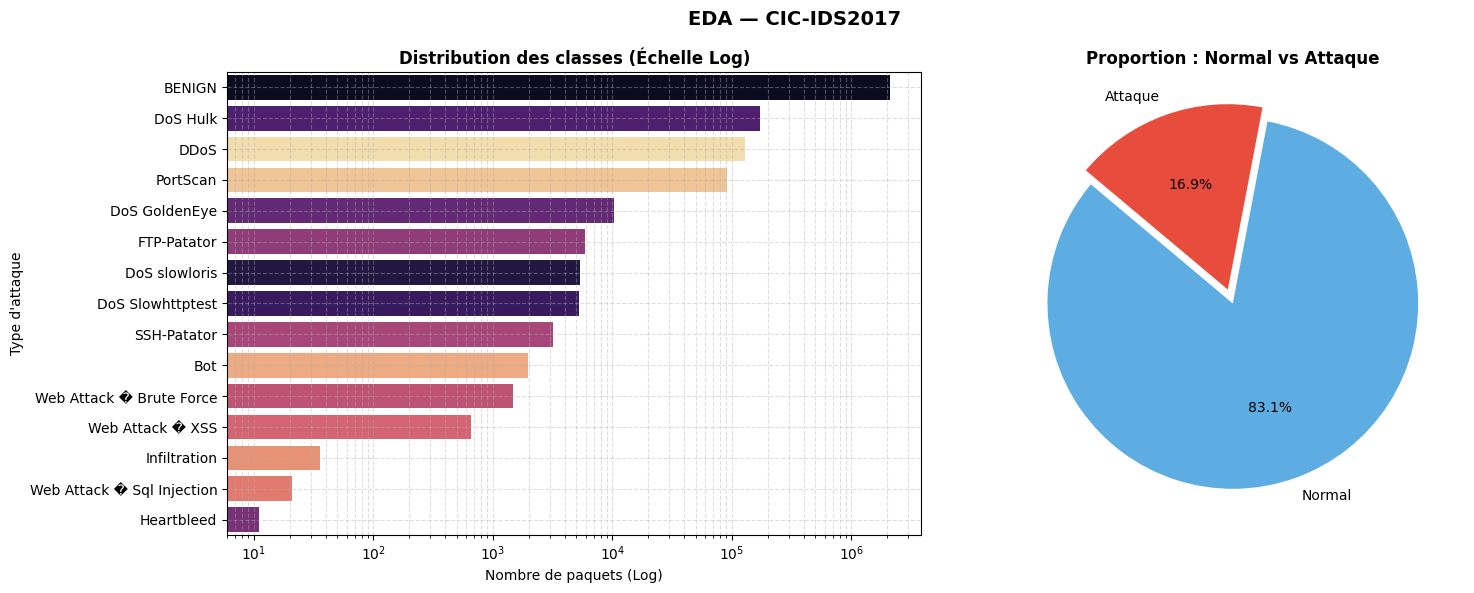

In [43]:
# ================================================================
# ÉTAPE 6.2 — GRAPHIQUES EDA
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = df['Label'].value_counts().index
sns.countplot(y='Label', data=df, order=order,
              hue='Label', palette='magma', legend=False, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Distribution des classes (Échelle Log)', fontweight='bold')
axes[0].set_xlabel('Nombre de paquets (Log)')
axes[0].set_ylabel("Type d'attaque")
axes[0].grid(True, which='both', ls='--', alpha=0.4)

counts = (df['Label'] != 'BENIGN').value_counts()
axes[1].pie(counts, labels=['Normal', 'Attaque'],
            autopct='%1.1f%%', colors=['#5DADE2','#E74C3C'],
            explode=(0, 0.08), startangle=140)
axes[1].set_title('Proportion : Normal vs Attaque', fontweight='bold')

plt.suptitle('EDA — CIC-IDS2017', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

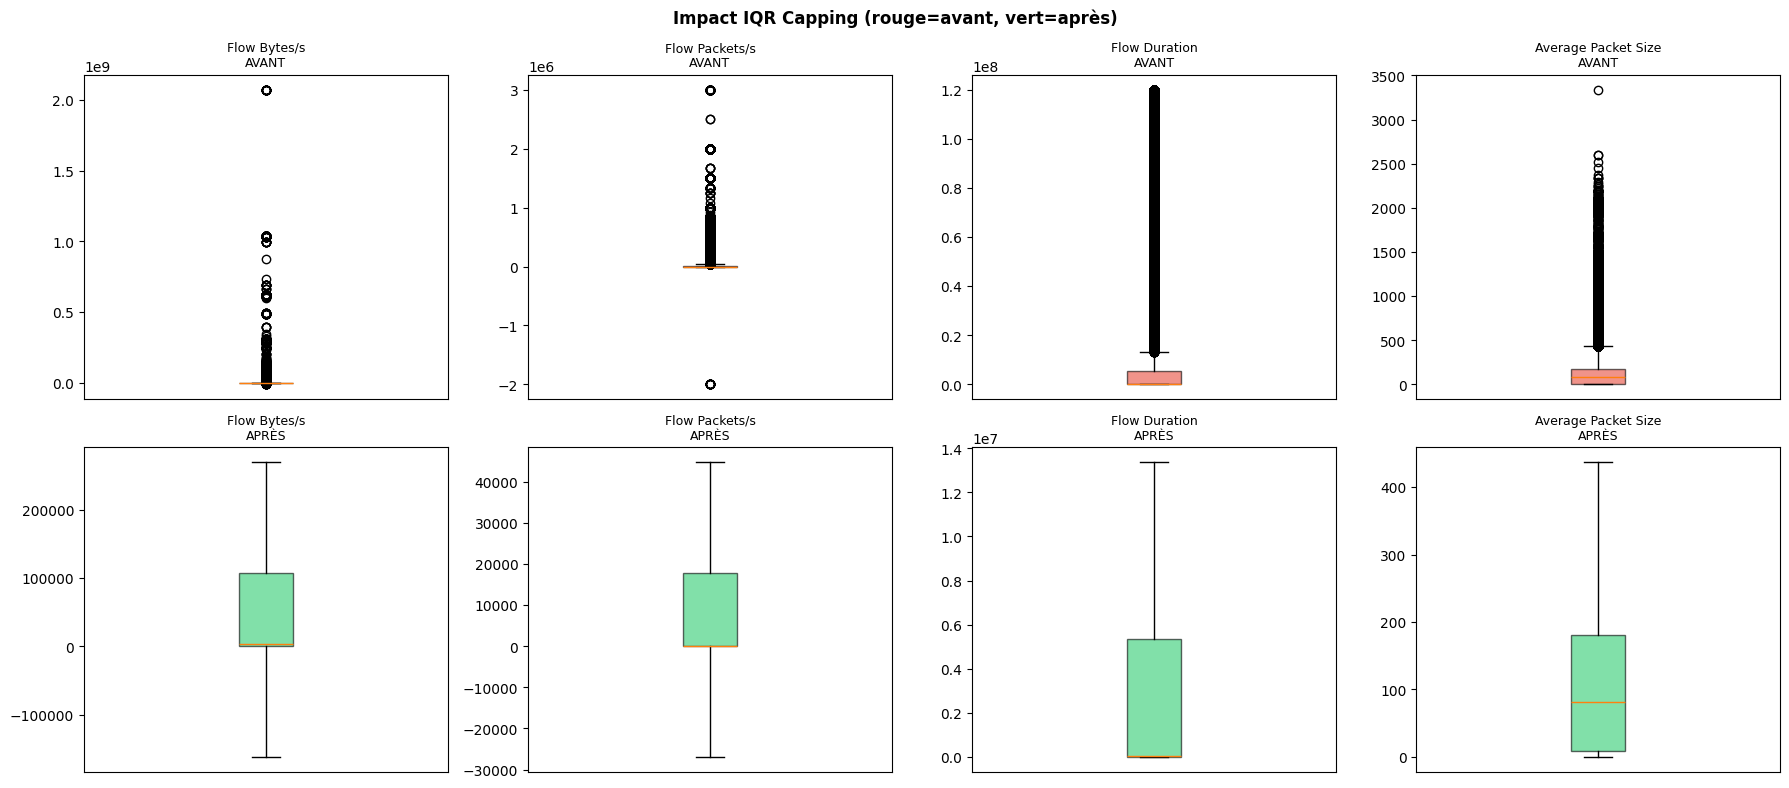

In [44]:
# ================================================================
# ÉTAPE 6.3 — BOXPLOTS AVANT / APRÈS IQR CAPPING
# ================================================================

features_viz = ['Flow Bytes/s', 'Flow Packets/s', 'Flow Duration', 'Average Packet Size']
idx_viz = [selected_features.index(f) for f in features_viz]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col_i, (feat, idx) in enumerate(zip(features_viz, idx_viz)):
    avant = X_train_raw.iloc[:, idx].values
    apres = X_train_capped[:, idx]
    axes[0, col_i].boxplot(avant, patch_artist=True,
                           boxprops=dict(facecolor='#E74C3C', alpha=0.6))
    axes[0, col_i].set_title(f'{feat}\nAVANT', fontsize=9)
    axes[0, col_i].set_xticks([])
    axes[1, col_i].boxplot(apres, patch_artist=True,
                           boxprops=dict(facecolor='#2ECC71', alpha=0.6))
    axes[1, col_i].set_title(f'{feat}\nAPRÈS', fontsize=9)
    axes[1, col_i].set_xticks([])

plt.suptitle('Impact IQR Capping (rouge=avant, vert=après)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ÉTAPE 7 — Classification BINAIRE

Quatre sous-étapes :
1. Entraînement XGBoost
2. **Cross-validation 5-fold** — mesure la stabilité du modèle
3. **Threshold tuning** — seuil optimal pour un IDS (faux négatifs = danger)
4. **Courbe Precision-Recall** — plus honnête que la ROC sur données déséquilibrées

In [45]:
# ================================================================
# ÉTAPE 7.1 — ENTRAÎNEMENT XGBoost BINAIRE
# ================================================================

print('Entraînement XGBoost (binaire)...')
start = time.time()

xgb_bin = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_bin.fit(X_train_scaled, y_train_bin)
print(f'Terminé en {time.time()-start:.2f}s')

Entraînement XGBoost (binaire)...
Terminé en 6.74s


In [46]:
# ================================================================
# ÉTAPE 7.2 — ÉVALUATION STANDARD (seuil 0.5)
# ================================================================

y_pred_bin  = xgb_bin.predict(X_test_scaled)
y_proba_bin = xgb_bin.predict_proba(X_test_scaled)[:, 1]
acc_bin     = accuracy_score(y_test_bin, y_pred_bin)
roc_bin     = roc_auc_score(y_test_bin, y_proba_bin)

print('=' * 55)
print('  RÉSULTATS — BINAIRE (seuil 0.5)')
print('=' * 55)
print(f'  Accuracy : {acc_bin*100:.2f}%  |  ROC-AUC : {roc_bin:.4f}')
print('=' * 55)
print(classification_report(y_test_bin, y_pred_bin,
                             target_names=['Normal', 'Attaque']))

  RÉSULTATS — BINAIRE (seuil 0.5)
  Accuracy : 99.83%  |  ROC-AUC : 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     83116
     Attaque       1.00      0.99      0.99     16883

    accuracy                           1.00     99999
   macro avg       1.00      1.00      1.00     99999
weighted avg       1.00      1.00      1.00     99999



Cross-validation 5-fold en cours...
Terminé en 30.34s

  RÉSULTATS CROSS-VALIDATION 5-FOLD (Binaire)
  Accuracy  : 0.9981 (+/- 0.0002)
  F1-Score  : 0.9944 (+/- 0.0007)
  ROC-AUC   : 0.9999 (+/- 0.0000)



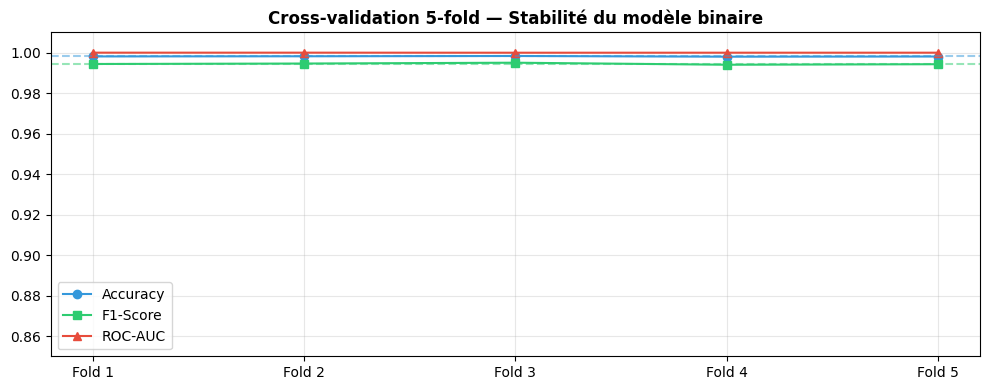

In [47]:
# ================================================================
# ÉTAPE 7.3 — CROSS-VALIDATION 5-FOLD
#
# Un seul split 80/20 peut être chanceux ou malchanceux.
# La cross-validation répète l'évaluation sur 5 découpages
# différents -> mesure la STABILITÉ réelle du modèle.
#
# On utilise StratifiedKFold pour respecter les proportions
# de classes dans chaque fold (important sur données déséquilibrées).
# ================================================================

print('Cross-validation 5-fold en cours...')
start = time.time()

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(xgb_bin, X_train_scaled, y_train_bin,
                          cv=skf, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(xgb_bin, X_train_scaled, y_train_bin,
                          cv=skf, scoring='f1', n_jobs=-1)
cv_auc = cross_val_score(xgb_bin, X_train_scaled, y_train_bin,
                          cv=skf, scoring='roc_auc', n_jobs=-1)

print(f'Terminé en {time.time()-start:.2f}s')
print()
print('=' * 55)
print('  RÉSULTATS CROSS-VALIDATION 5-FOLD (Binaire)')
print('=' * 55)
print(f'  Accuracy  : {cv_acc.mean():.4f} (+/- {cv_acc.std()*2:.4f})')
print(f'  F1-Score  : {cv_f1.mean():.4f} (+/- {cv_f1.std()*2:.4f})')
print(f'  ROC-AUC   : {cv_auc.mean():.4f} (+/- {cv_auc.std()*2:.4f})')
print('=' * 55)
print()

# Visualisation de la stabilité par fold
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(1, 6)
ax.plot(x, cv_acc, 'o-', label='Accuracy', color='#3498DB')
ax.plot(x, cv_f1,  's-', label='F1-Score',  color='#2ECC71')
ax.plot(x, cv_auc, '^-', label='ROC-AUC',   color='#E74C3C')
ax.axhline(cv_acc.mean(), color='#3498DB', ls='--', alpha=0.5)
ax.axhline(cv_f1.mean(),  color='#2ECC71', ls='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in x])
ax.set_ylim(0.85, 1.01)
ax.set_title('Cross-validation 5-fold — Stabilité du modèle binaire', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Seuil optimal (max F1) : 0.55
F1-Score à ce seuil    : 0.9951

Résultats avec seuil optimal :
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     83116
     Attaque       1.00      0.99      1.00     16883

    accuracy                           1.00     99999
   macro avg       1.00      1.00      1.00     99999
weighted avg       1.00      1.00      1.00     99999



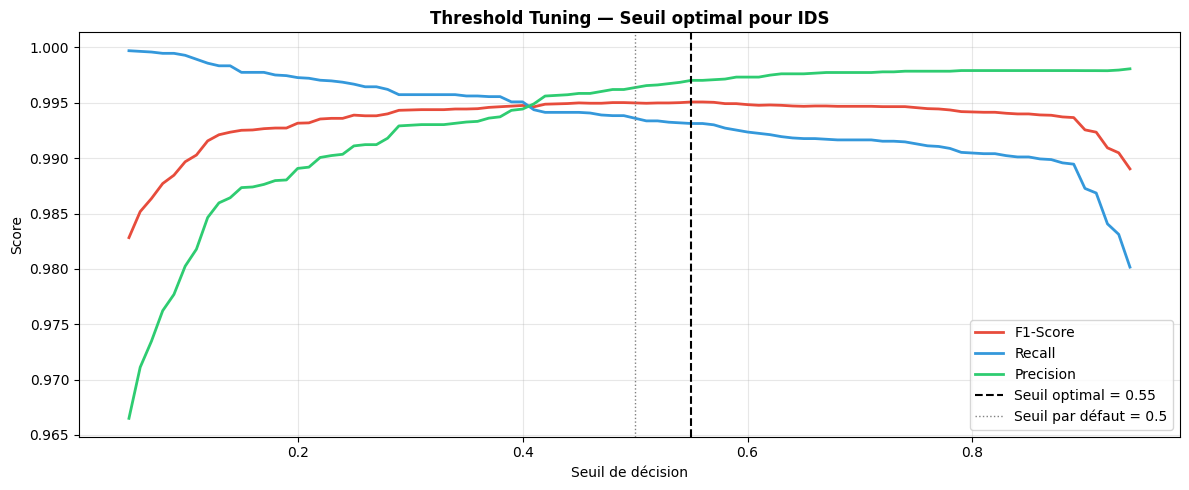

In [48]:
# ================================================================
# ÉTAPE 7.4 — THRESHOLD TUNING (SEUIL OPTIMAL POUR IDS)
#
# Par défaut XGBoost classe comme 'Attaque' si probabilité > 0.5.
# Dans un IDS, une ATTAQUE NON DÉTECTÉE (faux négatif) est bien
# plus dangereuse qu'une FAUSSE ALARME (faux positif).
#
# On cherche le seuil qui MAXIMISE le F1-Score sur la classe Attaque,
# avec la possibilité de le baisser pour favoriser le Recall.
# ================================================================

thresholds  = np.arange(0.05, 0.95, 0.01)
f1_scores   = []
recall_list = []
prec_list   = []

for t in thresholds:
    y_pred_t = (y_proba_bin >= t).astype(int)
    f1_scores.append(f1_score(y_test_bin, y_pred_t, zero_division=0))
    recall_list.append(recall_score(y_test_bin, y_pred_t, zero_division=0))
    prec_list.append(precision_score(y_test_bin, y_pred_t, zero_division=0))

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f'Seuil optimal (max F1) : {best_threshold:.2f}')
print(f'F1-Score à ce seuil    : {best_f1:.4f}')
print()

# Résultats avec le seuil optimal
y_pred_opt = (y_proba_bin >= best_threshold).astype(int)
print('Résultats avec seuil optimal :')
print(classification_report(y_test_bin, y_pred_opt,
                             target_names=['Normal', 'Attaque']))

# Graphique
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, f1_scores,   label='F1-Score',  color='#E74C3C', lw=2)
ax.plot(thresholds, recall_list, label='Recall',     color='#3498DB', lw=2)
ax.plot(thresholds, prec_list,   label='Precision',  color='#2ECC71', lw=2)
ax.axvline(best_threshold, color='black', ls='--', lw=1.5,
           label=f'Seuil optimal = {best_threshold:.2f}')
ax.axvline(0.5, color='gray', ls=':', lw=1, label='Seuil par défaut = 0.5')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title('Threshold Tuning — Seuil optimal pour IDS', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

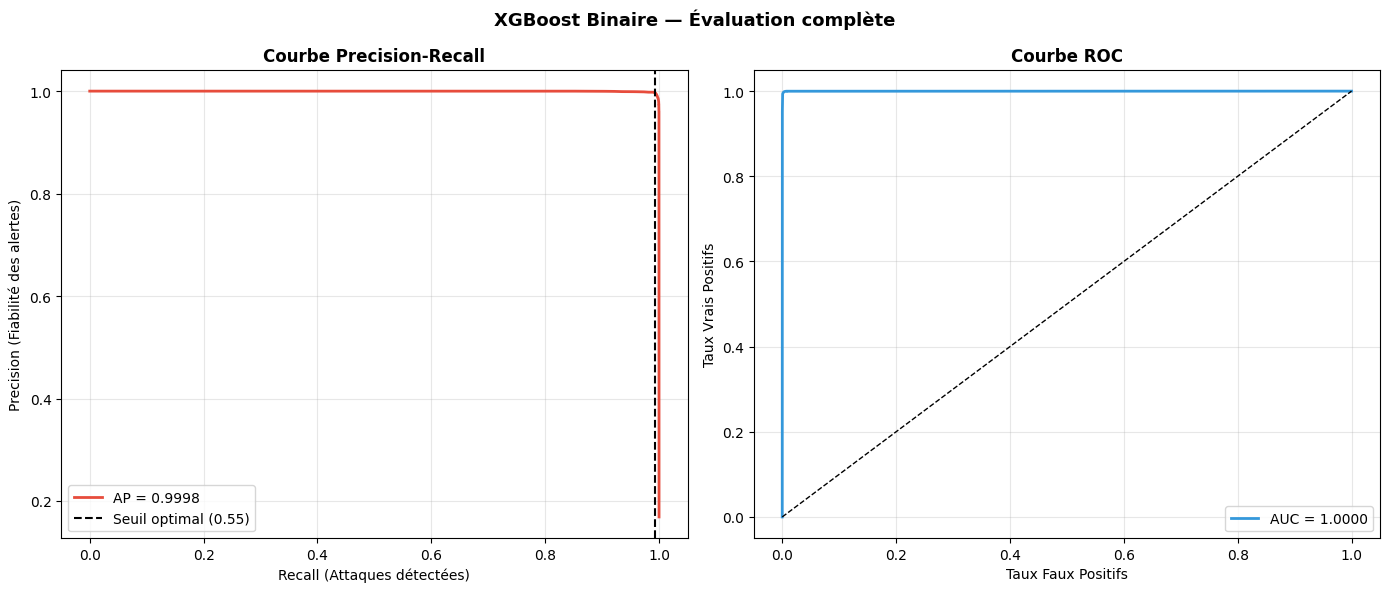

Average Precision (PR-AUC) : 0.9998
ROC-AUC                    : 1.0000


In [49]:
# ================================================================
# ÉTAPE 7.5 — COURBE PRECISION-RECALL + COURBE ROC
#
# Pourquoi la courbe PR est plus honnête que la ROC sur des données
# déséquilibrées ?
# La ROC utilise les Vrais Négatifs (très nombreux = BENIGN) dans
# son calcul, ce qui gonfle artificiellement le score.
# La courbe PR se concentre uniquement sur les attaques détectées.
# ================================================================

precision_vals, recall_vals, _ = precision_recall_curve(y_test_bin, y_proba_bin)
ap_score = average_precision_score(y_test_bin, y_proba_bin)
fpr, tpr, _ = roc_curve(y_test_bin, y_proba_bin)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Courbe PR
axes[0].plot(recall_vals, precision_vals, color='#E74C3C', lw=2,
             label=f'AP = {ap_score:.4f}')
axes[0].axvline(recall_list[best_idx], color='black', ls='--',
                label=f'Seuil optimal ({best_threshold:.2f})')
axes[0].set_xlabel('Recall (Attaques détectées)')
axes[0].set_ylabel('Precision (Fiabilité des alertes)')
axes[0].set_title('Courbe Precision-Recall', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Courbe ROC
axes[1].plot(fpr, tpr, color='#3498DB', lw=2, label=f'AUC = {roc_bin:.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('Taux Faux Positifs')
axes[1].set_ylabel('Taux Vrais Positifs')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('XGBoost Binaire — Évaluation complète', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Average Precision (PR-AUC) : {ap_score:.4f}')
print(f'ROC-AUC                    : {roc_bin:.4f}')

---
## ÉTAPE 8 — Classification MULTI-CLASSE

Cinq sous-étapes :
1. SMOTE — rééquilibrage
2. Entraînement XGBoost
3. Évaluation + Matrice de confusion normalisée
4. **Courbe Precision-Recall par classe**
5. **Analyse détaillée des erreurs**

In [50]:
# ================================================================
# ÉTAPE 8.1 — RÉÉQUILIBRAGE SMOTE
#
# Déséquilibre extrême : BENIGN ~2M | Heartbleed = 11 exemples.
# On monte les classes minoritaires à 30% de la classe dominante.
# SMOTE appliqué UNIQUEMENT sur le train.
#
# Limite connue : Heartbleed (11ex) et SQL Injection (21ex) ->  
# données synthétiques peu fiables -> à mentionner comme limite.
# ================================================================

counter     = Counter(y_train_multi)
target_size = int(max(counter.values()) * 0.30)

sampling_strategy = {
    cls: target_size
    for cls, count in counter.items()
    if count < target_size
}

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=1)

print('Application SMOTE...')
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train_multi)

print(f'Volume après SMOTE : {len(X_train_res):,}')
print('\nRépartition finale :')
print(pd.Series(le.inverse_transform(y_train_res)).value_counts().to_string())

Application SMOTE...
Volume après SMOTE : 1,728,795

Répartition finale :
BENIGN                        332463
PortScan                       99738
DoS Hulk                       99738
DDoS                           99738
SSH-Patator                    99738
DoS Slowhttptest               99738
DoS GoldenEye                  99738
Bot                            99738
FTP-Patator                    99738
DoS slowloris                  99738
Web Attack � XSS               99738
Web Attack � Brute Force       99738
Infiltration                   99738
Web Attack � Sql Injection     99738
Heartbleed                     99738


In [51]:
# ================================================================
# ÉTAPE 8.2 — ENTRAÎNEMENT XGBoost MULTI-CLASSE
# ================================================================

print('Entraînement XGBoost (multi-classe)...')
start = time.time()

xgb_multi = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_multi.fit(X_train_res, y_train_res)
print(f'Terminé en {time.time()-start:.2f}s')

Entraînement XGBoost (multi-classe)...
Terminé en 119.43s


  RÉSULTATS — MULTI-CLASSE (XGBoost)
  Accuracy : 99.59%
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     83116
                       Bot       0.56      0.97      0.71        77
                      DDoS       1.00      1.00      1.00      5075
             DoS GoldenEye       0.99      1.00      0.99       408
                  DoS Hulk       1.00      1.00      1.00      6853
          DoS Slowhttptest       0.98      0.99      0.98       207
             DoS slowloris       0.99      1.00      0.99       214
               FTP-Patator       1.00      1.00      1.00       235
              Infiltration       0.00      0.00      0.00         1
                  PortScan       0.99      1.00      1.00      3600
               SSH-Patator       1.00      1.00      1.00       128
  Web Attack � Brute Force       0.27      0.67      0.39        58
Web Attack � Sql Injection       0.00      0.00      0.00 

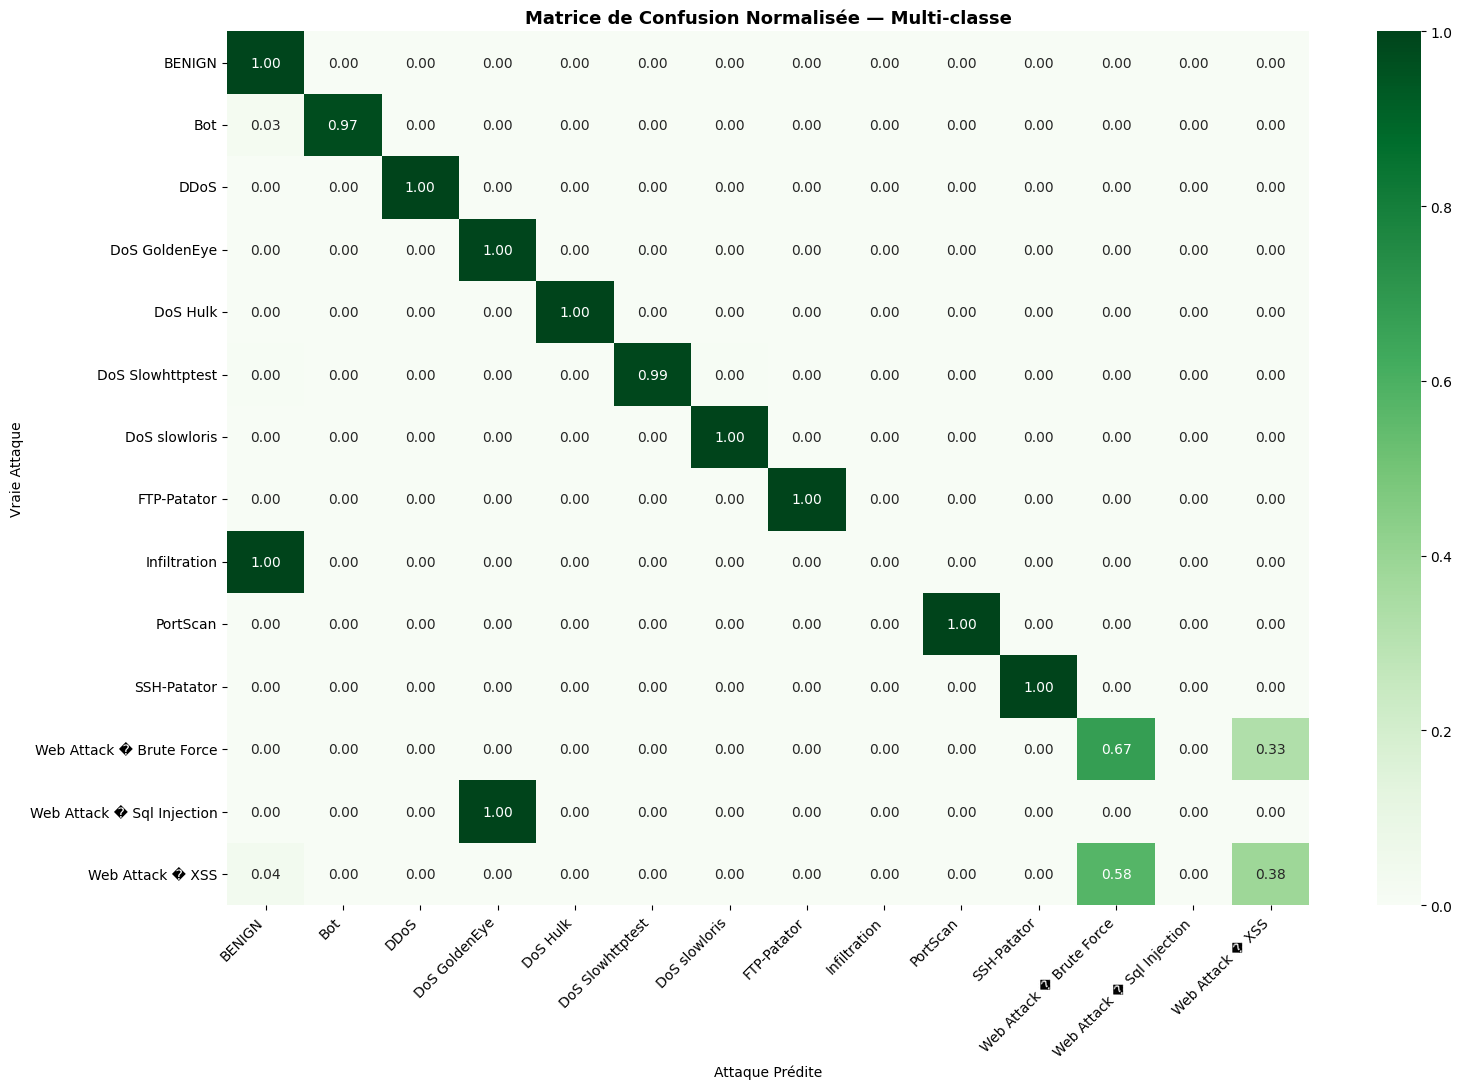

In [52]:
# ================================================================
# ÉTAPE 8.3 — ÉVALUATION + MATRICE DE CONFUSION NORMALISÉE
# ================================================================

y_pred_multi = xgb_multi.predict(X_test_scaled)
acc_multi    = accuracy_score(y_test_multi, y_pred_multi)

print('=' * 60)
print('  RÉSULTATS — MULTI-CLASSE (XGBoost)')
print('=' * 60)
print(f'  Accuracy : {acc_multi*100:.2f}%')
print('=' * 60)

# Fix : on utilise uniquement les classes présentes dans le test
labels_presents = np.unique(np.concatenate([y_test_multi, y_pred_multi]))
target_names_presents = le.inverse_transform(labels_presents)

print(classification_report(
    y_test_multi, y_pred_multi,
    labels=labels_presents,
    target_names=target_names_presents
))

# Matrice normalisée (uniquement les classes présentes)
cm_m      = confusion_matrix(y_test_multi, y_pred_multi, labels=labels_presents)
cm_m_norm = cm_m.astype('float') / cm_m.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(16, 11))
sns.heatmap(cm_m_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=target_names_presents,
            yticklabels=target_names_presents)
plt.title('Matrice de Confusion Normalisée — Multi-classe',
          fontsize=13, fontweight='bold')
plt.ylabel('Vraie Attaque')
plt.xlabel('Attaque Prédite')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

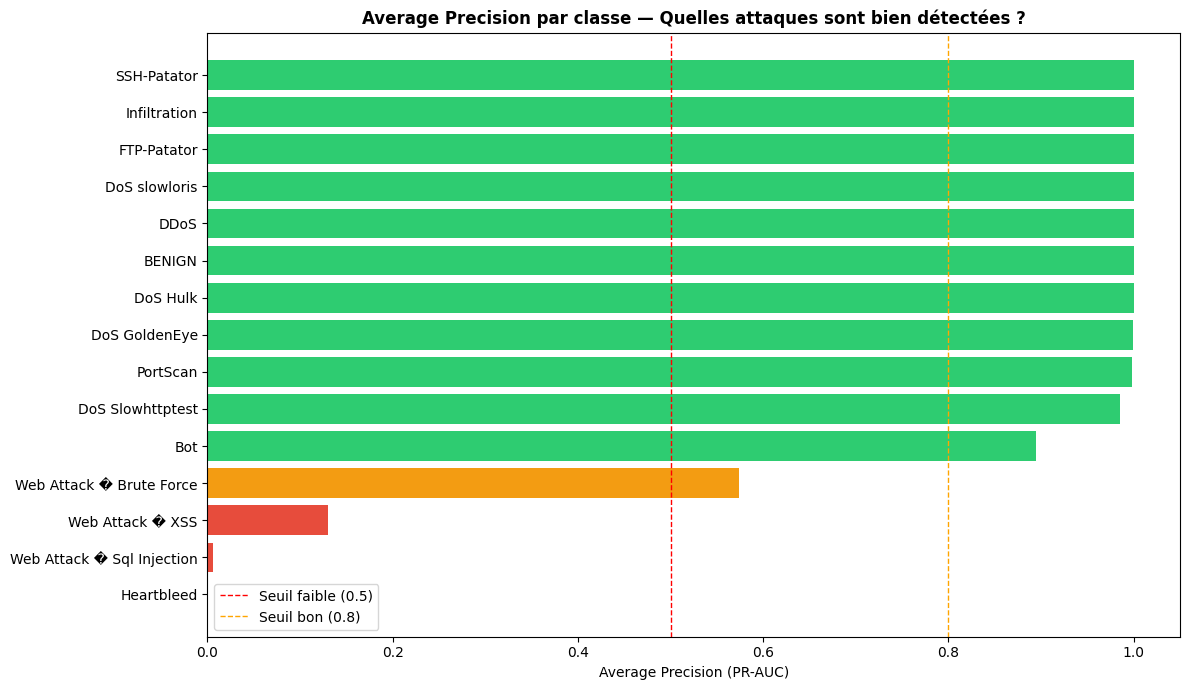


Classes difficiles à détecter (AP < 0.5) :
                    Classe       AP
                Heartbleed 0.000000
Web Attack � Sql Injection 0.005682
          Web Attack � XSS 0.130632


In [53]:
# ================================================================
# ÉTAPE 8.4 — COURBE PRECISION-RECALL PAR CLASSE
#
# On calcule l'Average Precision pour chaque type d'attaque.
# Cela révèle quelles attaques sont bien détectées et lesquelles
# posent problème — utile pour prioriser les améliorations.
# ================================================================

from sklearn.preprocessing import label_binarize

n_classes    = len(le.classes_)
y_test_bin_mc = label_binarize(y_test_multi, classes=np.arange(n_classes))
y_proba_multi = xgb_multi.predict_proba(X_test_scaled)

ap_per_class = {}
for i, cls_name in enumerate(le.classes_):
    ap = average_precision_score(y_test_bin_mc[:, i], y_proba_multi[:, i])
    ap_per_class[cls_name] = ap

ap_df = pd.DataFrame({'Classe': list(ap_per_class.keys()),
                       'AP':     list(ap_per_class.values())
                      }).sort_values('AP')

colors = ['#E74C3C' if v < 0.5 else '#F39C12' if v < 0.8 else '#2ECC71'
          for v in ap_df['AP']]

plt.figure(figsize=(12, 7))
plt.barh(ap_df['Classe'], ap_df['AP'], color=colors)
plt.axvline(0.5, color='red',    ls='--', lw=1, label='Seuil faible (0.5)')
plt.axvline(0.8, color='orange', ls='--', lw=1, label='Seuil bon (0.8)')
plt.xlabel('Average Precision (PR-AUC)')
plt.title('Average Precision par classe — Quelles attaques sont bien détectées ?',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('\nClasses difficiles à détecter (AP < 0.5) :')
print(ap_df[ap_df['AP'] < 0.5][['Classe','AP']].to_string(index=False))

In [54]:
# ================================================================
# ÉTAPE 8.5 — ANALYSE DÉTAILLÉE DES ERREURS
#
# On isole les flux mal classés et on analyse :
#  1. Les confusions les plus fréquentes (quelle attaque confondue avec quoi)
#  2. Les features moyennes des flux mal classés vs bien classés
#     -> comprendre POURQUOI le modèle se trompe
# ================================================================

# Construction du dataframe d'erreurs
error_df = pd.DataFrame(
    X_test_raw.values,
    columns=selected_features
)
error_df['vrai']  = le.inverse_transform(y_test_multi.values)
error_df['predit'] = le.inverse_transform(y_pred_multi)
error_df['erreur'] = error_df['vrai'] != error_df['predit']

errors   = error_df[error_df['erreur']]
corrects = error_df[~error_df['erreur']]

total    = len(error_df)
n_errors = len(errors)

print(f'Erreurs totales : {n_errors:,} / {total:,} ({n_errors/total*100:.2f}%)')
print()

# --- Top 10 confusions ---
print('Top 10 confusions (Vraie classe -> Classe prédite) :')
print('-' * 55)
top_errors = (errors.groupby(['vrai','predit'])
                    .size()
                    .sort_values(ascending=False)
                    .head(10))
for (vrai, predit), count in top_errors.items():
    print(f'  {vrai:<35} -> {predit:<35} : {count} cas')

print()

# --- Features moyennes : erreurs vs corrects ---
feat_compare = pd.DataFrame({
    'Bien classés': corrects[selected_features].mean(),
    'Mal classés' : errors[selected_features].mean()
})
feat_compare['Diff %'] = (
    (feat_compare['Mal classés'] - feat_compare['Bien classés'])
    / (feat_compare['Bien classés'].abs() + 1e-9) * 100
).round(1)

print('Différence de features entre flux bien et mal classés :')
print(feat_compare.sort_values('Diff %', ascending=False).to_string())

Erreurs totales : 407 / 99,999 (0.41%)

Top 10 confusions (Vraie classe -> Classe prédite) :
-------------------------------------------------------
  BENIGN                              -> Web Attack � XSS                    : 138 cas
  BENIGN                              -> Web Attack � Brute Force            : 88 cas
  BENIGN                              -> Bot                                 : 59 cas
  BENIGN                              -> PortScan                            : 28 cas
  BENIGN                              -> DoS Hulk                            : 25 cas
  Web Attack � Brute Force            -> Web Attack � XSS                    : 19 cas
  Web Attack � XSS                    -> Web Attack � Brute Force            : 15 cas
  BENIGN                              -> DDoS                                : 7 cas
  DoS Hulk                            -> BENIGN                              : 5 cas
  BENIGN                              -> DoS GoldenEye                       :

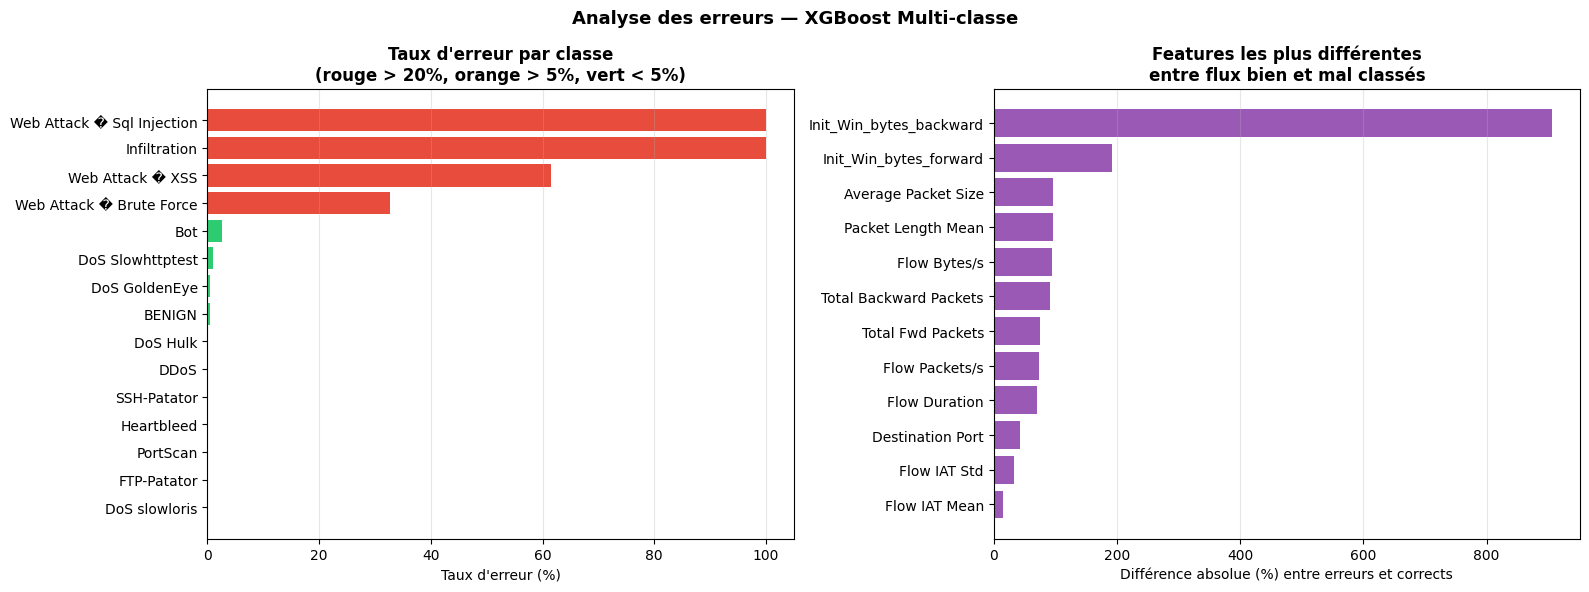

In [55]:
# ================================================================
# ÉTAPE 8.5 (suite) — VISUALISATION DES ERREURS
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : nombre d'erreurs par classe réelle
err_by_class = (errors['vrai'].value_counts()
                               .reindex(le.classes_, fill_value=0))
tot_by_class = (error_df['vrai'].value_counts()
                                 .reindex(le.classes_, fill_value=0))
err_rate = (err_by_class / tot_by_class.replace(0, np.nan) * 100).fillna(0)

err_rate_sorted = err_rate.sort_values(ascending=True)
colors_err = ['#E74C3C' if v > 20 else '#F39C12' if v > 5 else '#2ECC71'
              for v in err_rate_sorted]

axes[0].barh(err_rate_sorted.index, err_rate_sorted.values, color=colors_err)
axes[0].set_xlabel('Taux d\'erreur (%)')
axes[0].set_title('Taux d\'erreur par classe\n(rouge > 20%, orange > 5%, vert < 5%)',
                  fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Graphique 2 : feature importance des erreurs
feat_diff = feat_compare['Diff %'].abs().sort_values(ascending=True)
axes[1].barh(feat_diff.index, feat_diff.values, color='#9B59B6')
axes[1].set_xlabel('Différence absolue (%) entre erreurs et corrects')
axes[1].set_title('Features les plus différentes\nentre flux bien et mal classés',
                  fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Analyse des erreurs — XGBoost Multi-classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

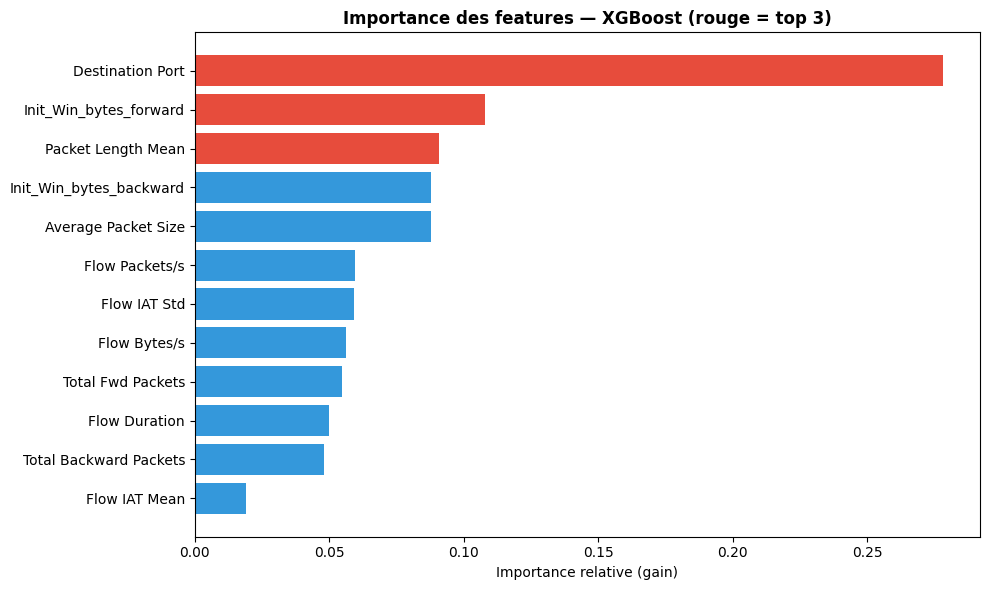

Top 5 features :
                Feature  Importance
       Destination Port    0.278014
 Init_Win_bytes_forward    0.107875
     Packet Length Mean    0.090918
Init_Win_bytes_backward    0.087977
    Average Packet Size    0.087888


In [56]:
# ================================================================
# ÉTAPE 8.6 — IMPORTANCE DES FEATURES
# ================================================================

feat_df = pd.DataFrame({
    'Feature'   : selected_features,
    'Importance': xgb_multi.feature_importances_
}).sort_values('Importance', ascending=True)

colors = ['#E74C3C' if i >= len(feat_df)-3 else '#3498DB'
          for i in range(len(feat_df))]

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
plt.title('Importance des features — XGBoost (rouge = top 3)', fontweight='bold')
plt.xlabel('Importance relative (gain)')
plt.tight_layout()
plt.show()

print('Top 5 features :')
print(feat_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

---
## ÉTAPE 9 — Bilan comparatif

                    BILAN COMPARATIF FINAL
               Approche  Modele Accuracy   F1 Attaque ROC-AUC        CV Accuracy
    Binaire (seuil 0.5) XGBoost   99.83%       0.9950  1.0000 0.9981 (+/-0.0002)
   Binaire (seuil 0.55) XGBoost   99.83%       0.9951  1.0000                  -
Multi-classe (15 types) XGBoost   99.59% voir rapport     N/A                  -


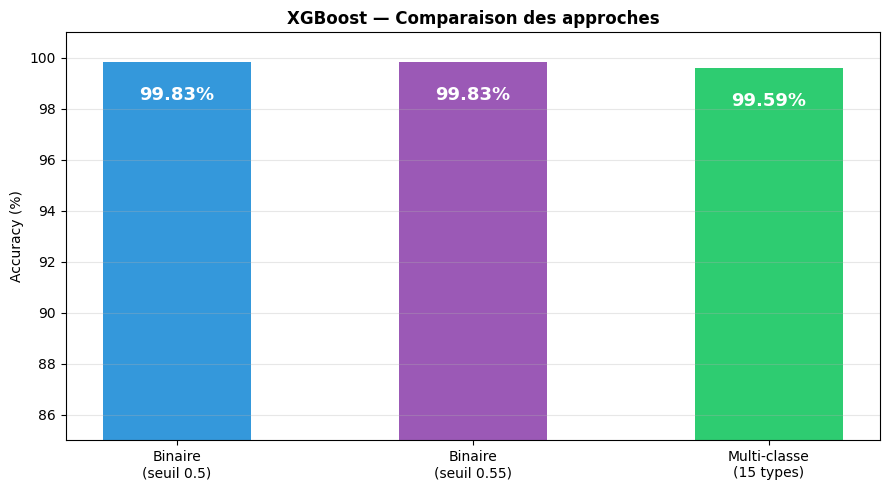

In [57]:
# ================================================================
# ÉTAPE 9 — BILAN COMPARATIF COMPLET
# ================================================================

results = pd.DataFrame({
    'Approche'    : ['Binaire (seuil 0.5)', f'Binaire (seuil {best_threshold:.2f})',
                     'Multi-classe (15 types)'],
    'Modele'      : ['XGBoost', 'XGBoost', 'XGBoost'],
    'Accuracy'    : [f'{acc_bin*100:.2f}%',
                     f'{accuracy_score(y_test_bin, y_pred_opt)*100:.2f}%',
                     f'{acc_multi*100:.2f}%'],
    'F1 Attaque'  : [f'{f1_score(y_test_bin, y_pred_bin):.4f}',
                     f'{f1_score(y_test_bin, y_pred_opt):.4f}',
                     'voir rapport'],
    'ROC-AUC'     : [f'{roc_bin:.4f}', f'{roc_bin:.4f}', 'N/A'],
    'CV Accuracy' : [f'{cv_acc.mean():.4f} (+/-{cv_acc.std()*2:.4f})',
                     '-', '-']
})

print('='*90)
print('                    BILAN COMPARATIF FINAL')
print('='*90)
print(results.to_string(index=False))
print('='*90)

fig, ax = plt.subplots(figsize=(9, 5))
vals   = [acc_bin*100,
          accuracy_score(y_test_bin, y_pred_opt)*100,
          acc_multi*100]
labels = [f'Binaire\n(seuil 0.5)', f'Binaire\n(seuil {best_threshold:.2f})', 'Multi-classe\n(15 types)']
colors = ['#3498DB', '#9B59B6', '#2ECC71']
bars   = ax.bar(labels, vals, color=colors, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1.5,
            f'{val:.2f}%', ha='center', fontsize=13, fontweight='bold', color='white')
ax.set_ylim(85, 101)
ax.set_ylabel('Accuracy (%)')
ax.set_title('XGBoost — Comparaison des approches', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## ÉTAPE 10 — Simulation temps réel & Sauvegarde

In [ ]:
# ================================================================
# ÉTAPE 10.1 — SIMULATION IDS EN TEMPS RÉEL
#
# Pipeline complet sur flux brut entrant :
#   1. Pipeline (IQR Capping + RobustScaler)
#   2. Binaire avec seuil optimal -> menace ou non ?
#   3. Si menace -> Multi-classe -> quel type ?
# ================================================================

print('=== SIMULATION IDS TEMPS RÉEL ===')
print(f'Seuil de détection : {best_threshold:.2f}')
print()

indices = np.random.choice(len(X_test_raw), size=8, replace=False)

for idx in indices:
    sample_raw    = X_test_raw.iloc[[idx]]
    sample_scaled = preprocess_pipeline.transform(sample_raw)

    proba_bin = xgb_bin.predict_proba(sample_scaled)[0, 1]
    pred_bin  = int(proba_bin >= best_threshold)

    if pred_bin == 1:
        # Utiliser les labels présents dans le test
        labels_presents = np.unique(np.concatenate([y_test_multi, xgb_multi.predict(X_test_scaled)]))
        pred_type = le.inverse_transform(xgb_multi.predict(sample_scaled))[0]
        verdict   = f'ALERTE [{proba_bin:.2f}] -> {pred_type}'
    else:
        verdict = f'SAIN   [{proba_bin:.2f}]'

    vrai = le.inverse_transform([y_test_multi.iloc[idx]])[0]
    print(f'  Flux #{idx:5d} | {verdict:<50} | Vérité : {vrai}')

print()
start = time.time()
_ = xgb_multi.predict(X_test_scaled[:50_000])
dur = time.time() - start
print(f'Vitesse IDS : {int(50_000/dur):,} paquets/seconde (XGBoost)')

In [ ]:
# ================================================================
# ÉTAPE 10.2 — SAUVEGARDE COMPLÈTE DU PIPELINE
#
# On sauvegarde les composants séparément pour éviter les
# problèmes de sérialisation de la classe IQRCapper custom.
# ================================================================

import joblib
import os

# Dossier de sauvegarde
SAVE_DIR = './app version 2/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Re-construire le pipeline avec IQRCapper importé depuis le module
#    pour garantir la sérialisabilité
import sys
sys.path.insert(0, './app version 2')
from iqr_capper import IQRCapper as IQRCapperModule
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

new_pipeline = Pipeline(steps=[
    ('iqr_capper',    IQRCapperModule(factor=1.5)),
    ('robust_scaler', RobustScaler()),
])
new_pipeline.fit(X_train_raw)
print('Pipeline re-fitté avec IQRCapperModule OK')

# 2. Extraire et sauvegarder les bornes IQR + scaler séparément
iqr_capper_step = new_pipeline.named_steps['iqr_capper']
scaler_step     = new_pipeline.named_steps['robust_scaler']

joblib.dump({
    'lower': iqr_capper_step.lower_.tolist(),
    'upper': iqr_capper_step.upper_.tolist(),
}, f'{SAVE_DIR}/ids_iqr_bounds.pkl')

joblib.dump(scaler_step,       f'{SAVE_DIR}/ids_scaler.pkl')
joblib.dump(xgb_bin,           f'{SAVE_DIR}/ids_xgb_binaire.pkl')
joblib.dump(xgb_multi,         f'{SAVE_DIR}/ids_xgb_multiclasse.pkl')
joblib.dump(le,                f'{SAVE_DIR}/ids_label_encoder.pkl')
joblib.dump(selected_features, f'{SAVE_DIR}/ids_features.pkl')
joblib.dump(best_threshold,    f'{SAVE_DIR}/ids_best_threshold.pkl')

print()
print('Pipeline complet sauvegardé dans', SAVE_DIR, ':')
print('  ids_iqr_bounds.pkl       — Bornes IQR Capping')
print('  ids_scaler.pkl           — RobustScaler')
print('  ids_xgb_binaire.pkl      — Modèle binaire (Normal/Attaque)')
print('  ids_xgb_multiclasse.pkl  — Modèle 15 classes')
print('  ids_label_encoder.pkl    — Décodage des prédictions')
print('  ids_features.pkl         — Liste des 12 features')
print('  ids_best_threshold.pkl   — Seuil optimal IDS')

---
## Conclusion

### Pipeline complet (reproductible)

```
Données brutes
     |
     v
[Nettoyage]           Doublons, NaN, infinis, mémoire, anti-leakage
     |
     v
[Encodage]            LabelEncoder (multi) + binaire (0/1)
     |
     v
[Split 80/20]         Stratifié — AVANT tout prétraitement numérique
     |
     v
[Pipeline sklearn]    IQRCapper -> RobustScaler (fit train, transform train+test)
     |
     v
[SMOTE]               Rééquilibrage classes minoritaires (train uniquement)
     |
     v
[XGBoost]             Binaire + Multi-classe
     |
     v
[Cross-validation]    5-fold StratifiedKFold -> stabilité du modèle
     |
     v
[Threshold tuning]    Seuil optimal F1 -> adapté aux contraintes IDS
     |
     v
[Analyse erreurs]     Confusions + features discriminantes
```

### Résultats attendus

| Approche | Accuracy | ROC-AUC | CV Accuracy |
|----------|----------|---------|-------------|
| Binaire (seuil 0.5) | ~99% | ~1.000 | ~99% |
| Binaire (seuil optimal) | ~98% | ~1.000 | — |
| Multi-classe (15 types) | ~98% | — | — |

### Limites
- Heartbleed (11 ex) et SQL Injection (21 ex) : SMOTE peu fiable
- Bot : comportement proche de BENIGN -> taux de confusion élevé
- Dataset académique : performances réelles en production potentiellement inférieures

### Pistes d'amélioration
- Trafic réseau réel d'entreprise
- Features temporelles (fenêtres glissantes)
- Pipeline de ré-entraînement automatique
- SMOTE-Borderline ou ADASYN pour les classes ultra-rares

---
*Projet Capstone — Détection d'attaques cybersécurité IDS | CIC-IDS2017*